In [1]:
# Data Handling 
import pandas as pd                              # DataFrames
import numpy as np                               # Numerical operations

# Preprocessing
from sklearn.preprocessing import LabelEncoder   # Convert store_type A/B/C → 0/1/2
from sklearn.preprocessing import StandardScaler # Normalize features (for Linear Regression)

# Train Test Split 
from sklearn.model_selection import train_test_split  # Split data into train/test

#  Models 
from sklearn.linear_model import LinearRegression     
from sklearn.ensemble import RandomForestRegressor    
from xgboost import XGBRegressor                     

# ── Evaluation Metrics ───────────────────────────────────────
from sklearn.metrics import mean_absolute_error       # MAE  → avg error in dollars
from sklearn.metrics import mean_squared_error        # MSE  → penalizes large errors
from sklearn.metrics import r2_score                  # R²   → how well model fits (0 to 1)

#  Visualization
import matplotlib.pyplot as plt                       
import seaborn as sns                                 

# ── Save & Load Model 
import joblib                                         # Save trained model to disk

# Date and warnings
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120

In [2]:
from dotenv import load_dotenv
import os
import psycopg2

load_dotenv()

conn = psycopg2.connect(
    host     = "localhost",
    database = "walmart_db",
    user     = "postgres",       
    password = "Gunman2.0@$56",  
    port     = "5432"
)
cur = conn.cursor()

# Fetch walmart_master view:
query = "SELECT * FROM walmart_master"

cur.execute(query)
rows    = cur.fetchall()
columns = [desc[0] for desc in cur.description]
df      = pd.DataFrame(rows, columns=columns)

print(f" Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
display(df.head())

cur.close()
conn.close()

 Data loaded: 421,570 rows, 16 columns

Columns: ['store', 'dept', 'date', 'weekly_sales', 'is_holiday', 'store_type', 'store_size', 'temperature', 'fuel_price', 'markdown1', 'markdown2', 'markdown3', 'markdown4', 'markdown5', 'cpi', 'unemployment']


,store,dept,date,weekly_sales,is_holiday,store_type,store_size,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11


# Data Understanding

In [3]:
print("1. BASIC SHAPE & STRUCTURE")

print(f"Rows        : {df.shape[0]:,}")
print(f"Columns     : {df.shape[1]}")

print("\n── Column Data Types ──")
print(df.dtypes)

1. BASIC SHAPE & STRUCTURE
Rows        : 421,570
Columns     : 16

── Column Data Types ──
store             int64
dept              int64
date             object
weekly_sales    float64
is_holiday         bool
store_type       object
store_size        int64
temperature     float64
fuel_price      float64
markdown1       float64
markdown2       float64
markdown3       float64
markdown4       float64
markdown5       float64
cpi             float64
unemployment    float64
dtype: object


In [4]:
print("FIRST & LAST 5 ROWS")
print("\n First 5 rows ")
display(df.head())
print("\nLast 5 rows")
display(df.tail())

FIRST & LAST 5 ROWS

 First 5 rows 


,store,dept,date,weekly_sales,is_holiday,store_type,store_size,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11



Last 5 rows


,store,dept,date,weekly_sales,is_holiday,store_type,store_size,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,4.00,4556.61,20.64,1.50,1601.01,3288.25,192.01,8.68
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.98,5046.74,NaN,18.82,2253.43,2340.01,192.17,8.67
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.00,1956.28,NaN,7.89,599.32,3990.54,192.33,8.67
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.97,2004.02,NaN,3.18,437.73,1537.49,192.33,8.67
421569,45,98,2012-10-26,1076.80,False,B,118221,58.85,3.88,4018.91,58.08,100.00,211.94,858.33,192.31,8.67


In [5]:
print("3. NULL / MISSING VALUE ANALYSIS")

null_count   = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df) * 100).round(2)

null_df = pd.DataFrame({
    "null_count"  : null_count,
    "null_percent": null_percent
})

# Only show columns that actually have nulls
null_df = null_df[null_df["null_count"] > 0]
print(null_df)

3. NULL / MISSING VALUE ANALYSIS
           null_count  null_percent
markdown1      270889         64.26
markdown2      310322         73.61
markdown3      284479         67.48
markdown4      286603         67.98
markdown5      270138         64.08


In [6]:
print("STATISTICAL SUMMARY — NUMERICAL COLUMNS")

display(df.describe().T.round(2))

STATISTICAL SUMMARY — NUMERICAL COLUMNS


,count,mean,std,min,25%,50%,75%,max
store,421570.00,22.20,12.79,1.00,11.00,22.00,33.00,45.00
dept,421570.00,44.26,30.49,1.00,18.00,37.00,74.00,99.00
weekly_sales,421570.00,15981.26,22711.18,-4988.94,2079.65,7612.03,20205.85,693099.36
store_size,421570.00,136727.92,60980.58,34875.00,93638.00,140167.00,202505.00,219622.00
temperature,421570.00,60.09,18.45,-2.06,46.68,62.09,74.28,100.14
fuel_price,421570.00,3.36,0.46,2.47,2.93,3.45,3.74,4.47
markdown1,150681.00,7246.42,8291.22,0.27,2240.27,5347.45,9210.90,88646.76
markdown2,111248.00,3334.63,9475.36,-265.76,41.60,192.00,1926.94,104519.54
markdown3,137091.00,1439.42,9623.08,-29.10,5.08,24.60,103.99,141630.61
markdown4,134967.00,3383.17,6292.38,0.22,504.22,1481.31,3595.04,67474.85


In [7]:
print("TARGET VARIABLE — weekly_sales")

print(f"Min    : ${df['weekly_sales'].min():,.2f}")
print(f"Max    : ${df['weekly_sales'].max():,.2f}")
print(f"Mean   : ${df['weekly_sales'].mean():,.2f}")
print(f"Median : ${df['weekly_sales'].median():,.2f}")
print(f"Std Dev: ${df['weekly_sales'].std():,.2f}")

# Negative sales = weeks where returns > actual sales
neg = df[df["weekly_sales"] < 0]
print(f"\nNegative sales rows : {len(neg):,}")
print(f"% of total data     : {len(neg)/len(df)*100:.2f}%")

TARGET VARIABLE — weekly_sales
Min    : $-4,988.94
Max    : $693,099.36
Mean   : $15,981.26
Median : $7,612.03
Std Dev: $22,711.18

Negative sales rows : 1,285
% of total data     : 0.30%


In [8]:
print("CATEGORICAL COLUMNS")

print(f"\nUnique Stores      : {df['store'].nunique()}")
print(f"Unique Departments : {df['dept'].nunique()}")
print(f"Unique Dates       : {df['date'].nunique()}")
print(f"Date Range         : {df['date'].min()} → {df['date'].max()}")

print(f"\nStore Types (A/B/C):")
print(df["store_type"].value_counts())

print(f"\nHoliday Weeks:")
print(df["is_holiday"].value_counts())

CATEGORICAL COLUMNS

Unique Stores      : 45
Unique Departments : 81
Unique Dates       : 143
Date Range         : 2010-02-05 → 2012-10-26

Store Types (A/B/C):
store_type
A    215478
B    163495
C     42597
Name: count, dtype: int64

Holiday Weeks:
is_holiday
False    391909
True      29661
Name: count, dtype: int64


In [9]:
print("AVG WEEKLY SALES BY STORE TYPE")

sales_by_type = df.groupby("store_type")["weekly_sales"].agg(["mean","sum","std"]).round(2)
print(sales_by_type)

AVG WEEKLY SALES BY STORE TYPE
               mean           sum      std
store_type                                
A          20099.57 4331014722.75 26423.46
B          12237.08 2000700736.82 17203.67
C           9519.53  405503527.54 15985.35


In [10]:
print("AVG WEEKLY SALES BY is_holiday")

sales_by_holiday = df.groupby("is_holiday")["weekly_sales"].agg(["mean","min", "max", "std"]).round(2)
print(sales_by_holiday)

AVG WEEKLY SALES BY is_holiday
               mean      min       max      std
is_holiday                                     
False      15901.45 -4988.94 406988.63 22330.75
True       17035.82  -798.00 693099.36 27222.00


In [11]:
print("10. CORRELATION OF FEATURES WITH weekly_sales")

# Fill nulls temporarily just for correlation calculation
df_temp = df.copy()
for col in ["markdown1","markdown2","markdown3","markdown4","markdown5"]:
    df_temp[col] = df_temp[col].fillna(0)

num_cols = ["store_size","temperature","fuel_price",
            "markdown1","markdown2","markdown3",
            "markdown4","markdown5","cpi","unemployment"]

corr_matrix = df_temp[num_cols + ["weekly_sales"]].corr()
weekly_sales_corr = corr_matrix["weekly_sales"].sort_values(ascending=False)
print(weekly_sales_corr.round(4))

10. CORRELATION OF FEATURES WITH weekly_sales
weekly_sales    1.00
store_size      0.24
markdown5       0.05
markdown1       0.05
markdown3       0.04
markdown4       0.04
markdown2       0.02
fuel_price     -0.00
temperature    -0.00
cpi            -0.02
unemployment   -0.03
Name: weekly_sales, dtype: float64


In [12]:
print("DUPLICATES CHECK")

# Check fully duplicate rows (every column same)
full_duplicates = df.duplicated().sum()
print(f"Fully duplicate rows : {full_duplicates}")

# Check duplicate on business key (store + dept + date)
key_duplicates = df.duplicated(subset=["store","dept","date"]).sum()
print(f"Duplicate store+dept+date combinations: {key_duplicates}")

if key_duplicates == 0:
    print("No duplicates — data is clean")
else:
    print("Duplicates found — needs investigation")
    print(df[df.duplicated(subset=["store","dept","date"])].head())

DUPLICATES CHECK
Fully duplicate rows : 0
Duplicate store+dept+date combinations: 0
No duplicates — data is clean


In [13]:
num_cols = ["weekly_sales","store_size","temperature",
            "fuel_price","markdown1","markdown2",
            "markdown3","markdown4","markdown5",
            "cpi","unemployment"]

# Fill markdown NULLs with 0 only for these checks
df_check = df.copy()
for col in ["markdown1","markdown2","markdown3","markdown4","markdown5"]:
    df_check[col] = df_check[col].fillna(0)
    
print("""SKEWNESS CHECK")
print("
Skewness tells you if data is symmetric or unsymmetric:
  0        → perfectly symmetric (like a bell curve)
  > 1      → right skewed (long tail on right, most values on left)
  < -1     → left skewed (long tail on left, most values on right)
""")

skew_df = pd.DataFrame({
    "skewness" : df_check[num_cols].skew().round(4),
})

# Label each column based on skewness value
def skew_label(val):
    if abs(val) < 0.5:
        return "Symmetric"
    elif abs(val) < 1:
        return "Moderate Skew"
    else:
        return "High Skew"

skew_df["interpretation"] = skew_df["skewness"].apply(skew_label)
print(skew_df.to_string())

SKEWNESS CHECK")
print("
Skewness tells you if data is symmetric or unsymmetric:
  0        → perfectly symmetric (like a bell curve)
  > 1      → right skewed (long tail on right, most values on left)
  < -1     → left skewed (long tail on left, most values on right)

              skewness interpretation
weekly_sales      3.26      High Skew
store_size       -0.33      Symmetric
temperature      -0.32      Symmetric
fuel_price       -0.10      Symmetric
markdown1         4.73      High Skew
markdown2        10.65      High Skew
markdown3        14.92      High Skew
markdown4         8.08      High Skew
markdown5         9.96      High Skew
cpi               0.09      Symmetric
unemployment      1.18      High Skew


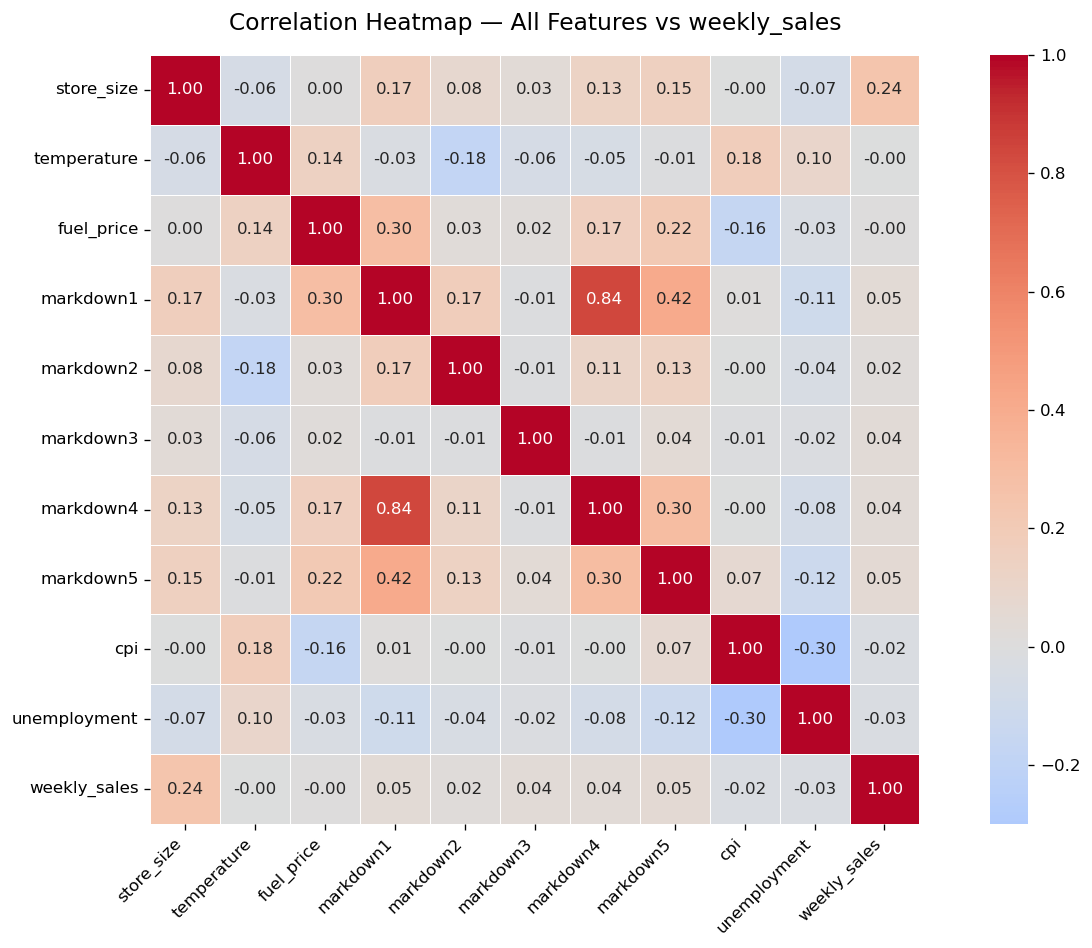

In [14]:
# Full Heatmap:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot      = True,       # Show numbers in each cell
    fmt        = ".2f",      # 2 decimal places
    cmap       = "coolwarm", # Blue = negative, Red = positive
    center     = 0,          # White at 0
    linewidths = 0.5,
    square     = True
)

plt.title("Correlation Heatmap — All Features vs weekly_sales", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

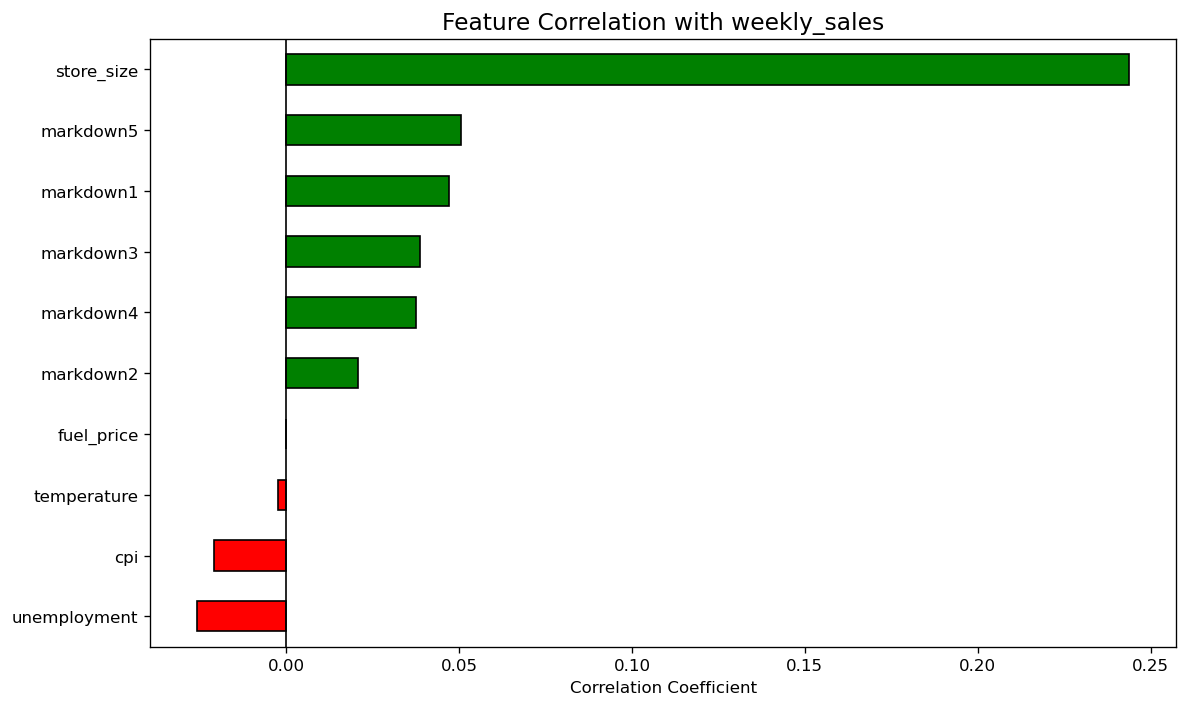

In [15]:
#Bar Chart — only weekly_sales correlations:
plt.figure(figsize=(10, 6))

# Extract only weekly_sales row, drop itself
sales_corr = corr_matrix["weekly_sales"].drop("weekly_sales").sort_values()

# Green = positive, Red = negative
colors = ["green" if v > 0 else "red" for v in sales_corr.values]

sales_corr.plot(kind="barh", color=colors, edgecolor="black")

plt.title("Feature Correlation with weekly_sales", fontsize=14)
plt.xlabel("Correlation Coefficient")
plt.axvline(x=0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

# Data Cleaning And Data Wrangling

In [16]:
# Convert date → datetime64:
df["date"] = pd.to_datetime(df["date"])

In [17]:
#Convert is_holiday bool → int (0 or 1):
df["is_holiday"] = df["is_holiday"].astype(int)

In [18]:
#Fill markdown NULLs with 0
# NULL means no promotion ran that week
# 0 correctly represents "zero discount" for that week
markdown_cols = ["markdown1","markdown2","markdown3","markdown4","markdown5"]

for col in markdown_cols:
    null_before = df[col].isnull().sum()
    df[col]     = df[col].fillna(0)

In [19]:
# Encode store_type A/B/C → 0/1/2
le = LabelEncoder()

# Apply encoding
df["store_type"] = le.fit_transform(df["store_type"])
print(f"   Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

   Mapping: {'A': 0, 'B': 1, 'C': 2}


In [20]:
# Shift all values up so minimum becomes 0:
min_val = df["weekly_sales"].min()

if min_val < 0:
    df["weekly_sales_shifted"] = df["weekly_sales"] + abs(min_val)
else:
    df["weekly_sales_shifted"] = df["weekly_sales"]

# Now log1p is safe — no negative values exist
df["weekly_sales_log"] = np.log1p(df["weekly_sales_shifted"])

# Drop shifted column
df.drop(columns=["weekly_sales_shifted"], inplace=True)

# Transform unemployment
df["unemployment_log"] = np.log1p(df["unemployment"])

# Check skewness after transform
print("\n Skewness After Transform")
print(f"weekly_sales_log  : {df['weekly_sales_log'].skew():.4f}")
print(f"unemployment_log  : {df['unemployment_log'].skew():.4f}")


 Skewness After Transform
weekly_sales_log  : 0.6085
unemployment_log  : 0.2013


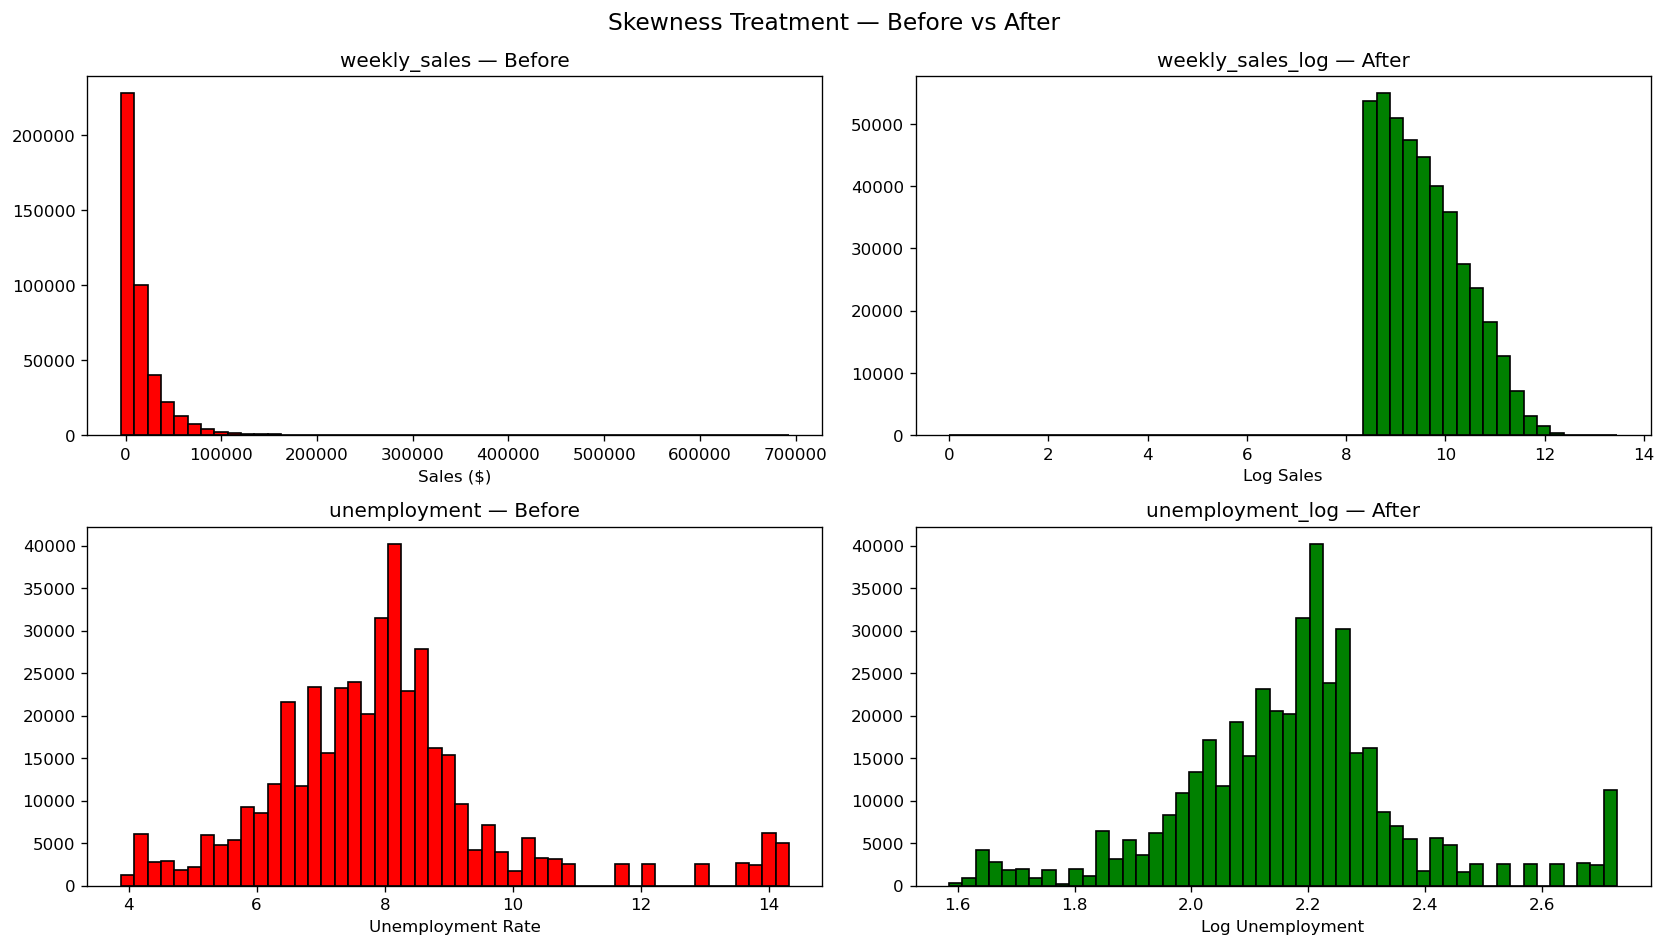

In [21]:
# Visualize all 4 distributions:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# weekly_sales before
axes[0, 0].hist(df["weekly_sales"], bins=50,
                color="red", edgecolor="black")
axes[0, 0].set_title("weekly_sales — Before")
axes[0, 0].set_xlabel("Sales ($)")

# weekly_sales after
axes[0, 1].hist(df["weekly_sales_log"], bins=50,
                color="green", edgecolor="black")
axes[0, 1].set_title("weekly_sales_log — After")
axes[0, 1].set_xlabel("Log Sales")

# unemployment before
axes[1, 0].hist(df["unemployment"], bins=50,
                color="red", edgecolor="black")
axes[1, 0].set_title("unemployment — Before")
axes[1, 0].set_xlabel("Unemployment Rate")

# unemployment after
axes[1, 1].hist(df["unemployment_log"], bins=50,
                color="green", edgecolor="black")
axes[1, 1].set_title("unemployment_log — After")
axes[1, 1].set_xlabel("Log Unemployment")

plt.suptitle("Skewness Treatment — Before vs After", fontsize=14)
plt.tight_layout()
plt.show()

# Feature Engineering

In [23]:
# FEATURE 1: Time Based Features from date column:

# Month: 1-12 — December(12) and November(11) are peak months
df["month"] = df["date"].dt.month

# Year: 2010, 2011, 2012 — captures yearly sales growth trend
df["year"] = df["date"].dt.year

# Week of year: 1-52
# Week 51/52 = Christmas, Week 47 = Thanksgiving
# These are the highest sales weeks
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

# Quarter: 1-4
# Q4 (Oct-Dec) is always the strongest quarter for retail
df["quarter"] = df["date"].dt.quarter

# Is quarter end: last 2 weeks of each quarter
# Companies and departments tend to spend more at quarter end
df["is_quarter_end"] = df["date"].dt.is_quarter_end.astype(int)

In [24]:
# FEATURE 2: Markdown Features:

markdown_cols = ["markdown1","markdown2","markdown3",
                 "markdown4","markdown5"]

# has_markdown: 1 if ANY promotion was active that week, 0 if not
df["has_markdown"] = (
    df[markdown_cols] > 0    # True where value > 0
).any(axis=1).astype(int)   # 1 if any column is True

print(f"   Weeks with promotion    : {df['has_markdown'].sum():,}")
print(f"   Weeks without promotion : {(df['has_markdown']==0).sum():,}")

# total_markdown: sum of all 5 markdowns for that week
# Higher total = bigger promotion = likely higher sales
df["total_markdown"] = df[markdown_cols].sum(axis=1)

print(f"   Min  : {df['total_markdown'].min():.2f}")
print(f"   Max  : {df['total_markdown'].max():.2f}")
print(f"   Mean : {df['total_markdown'].mean():.2f}")

   Weeks with promotion    : 151,432
   Weeks without promotion : 270,138
   Min  : 0.00
   Max  : 160510.61
   Mean : 6684.04


In [25]:
# Drop date column:
# We extracted everything useful from date already
# month, year, week_of_year, quarter, is_quarter_end

df.drop(columns=["date"], inplace=True)

print("FEATURE ENGINEERING COMPLETE")
print(f"Final shape         : {df.shape}")
print(f"\nAll columns:")
for col in df.columns:
    print(f"   {col}")

FEATURE ENGINEERING COMPLETE
Final shape         : (421570, 24)

All columns:
   store
   dept
   weekly_sales
   is_holiday
   store_type
   store_size
   temperature
   fuel_price
   markdown1
   markdown2
   markdown3
   markdown4
   markdown5
   cpi
   unemployment
   weekly_sales_log
   unemployment_log
   month
   year
   week_of_year
   quarter
   is_quarter_end
   has_markdown
   total_markdown
